# CAEG-Net: Context-Adaptive Expert Gating Network
## Short-Term Electricity Load Forecasting with Heterogeneous Temporal Experts and Dynamic Shrinkage
### Faculty Project Review & Viva Demonstration Notebook

---

**Project Title:** CAEG-Net: Context-Adaptive Expert Gating Network for Short-Term Electricity Load Forecasting  
**Author / Candidate:** Vinay Vishwanathan  
**Registration Number:** `[Registration Number]`  
**Department:** Department of Computer Science & Engineering / Advanced Predictive Analytics  
**Faculty Guide / Advisor:** `[Faculty Guide / Advisor]`  
**Execution Mode:** Demonstration & Defense Notebook (Fast CPU Execution, No Retraining)  
**Authoritative Final Model:** **CAEG-Net F2 (A2-OOF)** — $121,724$ Parameters  

---


---
## Section 2 — What is the Problem?

### The Core Challenge
In electric power grids, electricity cannot be stored cost-effectively at utility scale. Grid operators must balance total generation and demand on a continuous basis.

- **Primary Goal:** 24-hour day-ahead short-term load forecasting (STLF).
- **Why It Matters:** Informs generator unit commitment, economic dispatch, battery storage scheduling, and grid reliability.
- **The Difficulty:** Load time-series exhibit multi-scale patterns: intraday ramps, 24-hour diurnal rhythms, 7-day weekly cycles, and non-stationary demand shifts.

### Why Monolithic Neural Networks Struggle
- **Pure LSTM:** Strong at continuous recurrent memory, but slow to react to abrupt demand spikes.
- **Pure TCN:** Broad receptive field ($253$ hours) without recursive degradation, but can over-smooth localized transients.
- **Pure CNN:** Captures sharp local edge motifs, but lacks long-range sequential state tracking.

**The Solution:** Deploy three complementary temporal experts (LSTM, TCN, CNN) and coordinate them via an adaptive, context-aware router with dynamic shrinkage.


---
## Section 3 — Research Question

> ### 🎯 Core Research Question
> *"Can context-aware adaptive expert gating improve short-term electricity load forecasting by dynamically combining complementary LSTM, TCN, and CNN temporal experts?"*


---
## Section 4 — Datasets & Causal Partitioning Protocol

### Tri-Benchmark Grid Coverage
To ensure findings generalize across diverse grid topologies:
1. **PJM Interconnection (PJM):** Regional hourly operational load from the US Mid-Atlantic ($8,784$ hours, 1 leap year).
2. **GEFCom2014:** Global Energy Forecasting Competition operational benchmark ($78,888$ hours).
3. **UCI Electricity:** Portuguese grid demand aggregated from 15-minute intervals to hourly resolution ($26,304$ hours).

### Leakage-Free Chronological Protocol
- **Strict Chronological Splitting:** 70% Train, 15% Validation, 15% Test. No random temporal shuffling.
- **Train-Only Scaling:** Standardization parameters ($\mu, \sigma$) are computed strictly on the training partition.
- **Window Dimensions:** Input lookback $L = 168$ hours (7 days), forecast horizon $H = 24$ hours (1 day ahead).


In [1]:
# Environment setup and dataset inspection
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dynamic repository root resolution
cur = os.getcwd()
while cur and not os.path.exists(os.path.join(cur, "research")):
    parent = os.path.dirname(cur)
    if parent == cur:
        break
    cur = parent
repo_root = cur if os.path.exists(os.path.join(cur, "research")) else os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Set clean, faculty-friendly publication style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "figure.titlesize": 13,
    "figure.dpi": 150
})

datasets_summary = pd.DataFrame([
    {"Dataset Benchmark": "PJM Operational Load", "Temporal Span": "Oct 2023 - Oct 2024 (8,784 h)", "Resolution": "1 hour", "Lookback (L)": "168 h", "Horizon (H)": "24 h", "Test Windows": "1,294 (53 daily blocks)", "Unit": "MW"},
    {"Dataset Benchmark": "GEFCom2014", "Temporal Span": "Multi-Year (78,888 h)", "Resolution": "1 hour", "Lookback (L)": "168 h", "Horizon (H)": "24 h", "Test Windows": "10,944 (456 daily blocks)", "Unit": "kW"},
    {"Dataset Benchmark": "UCI Electricity Load", "Temporal Span": "2011 - 2014 (26,304 h)", "Resolution": "15-min -> 1 hour", "Lookback (L)": "168 h", "Horizon (H)": "24 h", "Test Windows": "3,922 (163 daily blocks)", "Unit": "MW"}
])

display(datasets_summary.set_index("Dataset Benchmark"))


,Temporal Span,Resolution,Lookback (L),Horizon (H),Test Windows,Unit
Dataset Benchmark,,,,,,
PJM Operational Load,"Oct 2023 - Oct 2024 (8,784 h)",1 hour,168 h,24 h,"1,294 (53 daily blocks)",MW
GEFCom2014,"Multi-Year (78,888 h)",1 hour,168 h,24 h,"10,944 (456 daily blocks)",kW
UCI Electricity Load,"2011 - 2014 (26,304 h)",15-min -> 1 hour,168 h,24 h,"3,922 (163 daily blocks)",MW


---
## Section 5 — System Architecture & Methodology

### Architectural Flow of CAEG-Net F2
1. **Heterogeneous Temporal Backbone:** Processes 168 hours of historical load through three specialized sub-networks:
   - **LSTM Expert:** 2-layer stacked LSTM tracking recurrent hidden states.
   - **TCN Expert:** 6 dilated causal convolutional residual blocks ($RF = 253 \text{ h} > 168 \text{ h}$).
   - **CNN Expert:** 3-stage multi-kernel Conv1D capturing sharp localized ramps.
2. **Context & OOF Features:** Computes trend, volatility, periodicity, and causally tracked out-of-fold expert error residuals.
3. **Adaptive Gating Network:** Computes dynamic convex routing weights ($w_{\text{LSTM}}, w_{\text{TCN}}, w_{\text{CNN}}$) via softmax.
4. **Adaptive Convex Fusion:** $\hat{y}_{\text{adaptive}} = \sum_{i=1}^3 w_i \hat{y}_i$.
5. **Confidence Fallback Head:** Blends the adaptive prediction with the equal-expert centroid $\hat{y}_{\text{equal}}$:
   $$\hat{y}_{\text{final}} = \lambda \hat{y}_{\text{adaptive}} + (1 - \lambda) \hat{y}_{\text{equal}}$$


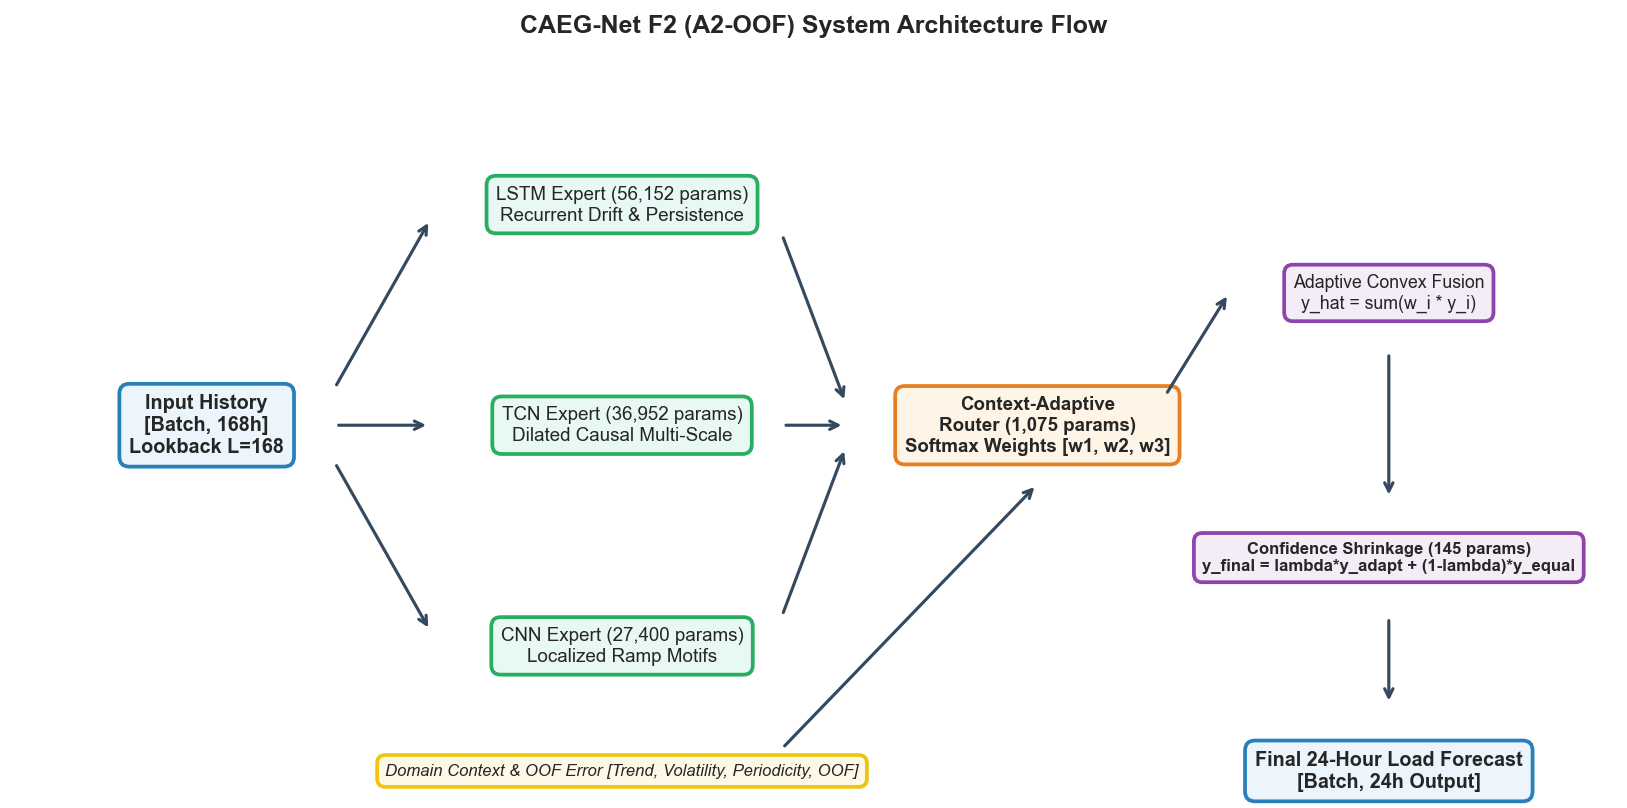

In [2]:
# Chart A: Architecture Flow Diagram
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(11, 5.5), facecolor='white')
ax.set_xlim(0, 100)
ax.set_ylim(100, 0)
ax.axis('off')

# Style definitions
box_blue = dict(boxstyle="round,pad=0.5", facecolor="#EBF5FB", edgecolor="#2980B9", lw=1.8)
box_green = dict(boxstyle="round,pad=0.5", facecolor="#E8F8F5", edgecolor="#27AE60", lw=1.8)
box_orange = dict(boxstyle="round,pad=0.5", facecolor="#FEF5E7", edgecolor="#E67E22", lw=1.8)
box_purple = dict(boxstyle="round,pad=0.5", facecolor="#F4ECF7", edgecolor="#8E44AD", lw=1.8)
box_gold = dict(boxstyle="round,pad=0.5", facecolor="#FEF9E7", edgecolor="#F1C40F", lw=1.8)

# Nodes
ax.text(12, 50, "Input History\n[Batch, 168h]\nLookback L=168", ha="center", va="center", bbox=box_blue, fontsize=9.5, fontweight="bold")

# Three Experts
ax.text(38, 20, "LSTM Expert (56,152 params)\nRecurrent Drift & Persistence", ha="center", va="center", bbox=box_green, fontsize=9)
ax.text(38, 50, "TCN Expert (36,952 params)\nDilated Causal Multi-Scale", ha="center", va="center", bbox=box_green, fontsize=9)
ax.text(38, 80, "CNN Expert (27,400 params)\nLocalized Ramp Motifs", ha="center", va="center", bbox=box_green, fontsize=9)

# Context Vector
ax.text(38, 97, "Domain Context & OOF Error [Trend, Volatility, Periodicity, OOF]", ha="center", va="center", bbox=box_gold, fontsize=8, style="italic")

# Router
ax.text(64, 50, "Context-Adaptive\nRouter (1,075 params)\nSoftmax Weights [w1, w2, w3]", ha="center", va="center", bbox=box_orange, fontsize=9, fontweight="bold")

# Fusion & Shrinkage
ax.text(86, 32, "Adaptive Convex Fusion\ny_hat = sum(w_i * y_i)", ha="center", va="center", bbox=box_purple, fontsize=8.5)
ax.text(86, 68, "Confidence Shrinkage (145 params)\ny_final = lambda*y_adapt + (1-lambda)*y_equal", ha="center", va="center", bbox=box_purple, fontsize=8, fontweight="bold")

# Final Output
ax.text(86, 97, "Final 24-Hour Load Forecast\n[Batch, 24h Output]", ha="center", va="center", bbox=box_blue, fontsize=9.5, fontweight="bold")

# Connecting Arrows
arrow_spec = dict(arrowstyle="->", lw=1.5, color="#34495E")
ax.annotate("", xy=(26, 22), xytext=(20, 45), arrowprops=arrow_spec)
ax.annotate("", xy=(26, 50), xytext=(20, 50), arrowprops=arrow_spec)
ax.annotate("", xy=(26, 78), xytext=(20, 55), arrowprops=arrow_spec)

ax.annotate("", xy=(52, 47), xytext=(48, 24), arrowprops=arrow_spec)
ax.annotate("", xy=(52, 50), xytext=(48, 50), arrowprops=arrow_spec)
ax.annotate("", xy=(52, 53), xytext=(48, 76), arrowprops=arrow_spec)
ax.annotate("", xy=(64, 58), xytext=(48, 94), arrowprops=arrow_spec)

ax.annotate("", xy=(76, 32), xytext=(72, 46), arrowprops=arrow_spec)
ax.annotate("", xy=(86, 60), xytext=(86, 40), arrowprops=arrow_spec)
ax.annotate("", xy=(86, 88), xytext=(86, 76), arrowprops=arrow_spec)

ax.set_title("CAEG-Net F2 (A2-OOF) System Architecture Flow", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


### How to explain this to faculty
"CAEG-Net F2 feeds 168 hours of historical load into three distinct temporal experts; a context-aware router dynamically combines their 24-hour predictions, while a confidence head blends the result with the equal ensemble to ensure operational stability."


---
## Section 6 — Model Architecture & Parameter Complexity

### Submodule Parameter Breakdown
CAEG-Net F2 has **$121,724$ total parameters**:
- **Backbone Subtotal:** $120,504$ parameters ($98.9\%$ of model).
- **Gating Overhead:** $1,075$ router parameters ($0.9\%$) + $145$ confidence head parameters ($0.1\%$).


,Role,Parameters,Share
Component,,,
LSTM Expert,Recurrent diurnal persistence,56152,46.1%
TCN Expert,Dilated causal multi-scale patterns,36952,30.4%
CNN Expert,Localized ramp feature extraction,27400,22.5%
Backbone Subtotal,Three temporal feature extractors,120504,98.9%
Adaptive Router,Dynamic context-driven weighting,1075,0.9%
Confidence Head,Dynamic shrinkage toward centroid,145,0.1%
TOTAL CAEG-Net F2,Full champion architecture,121724,100.0%


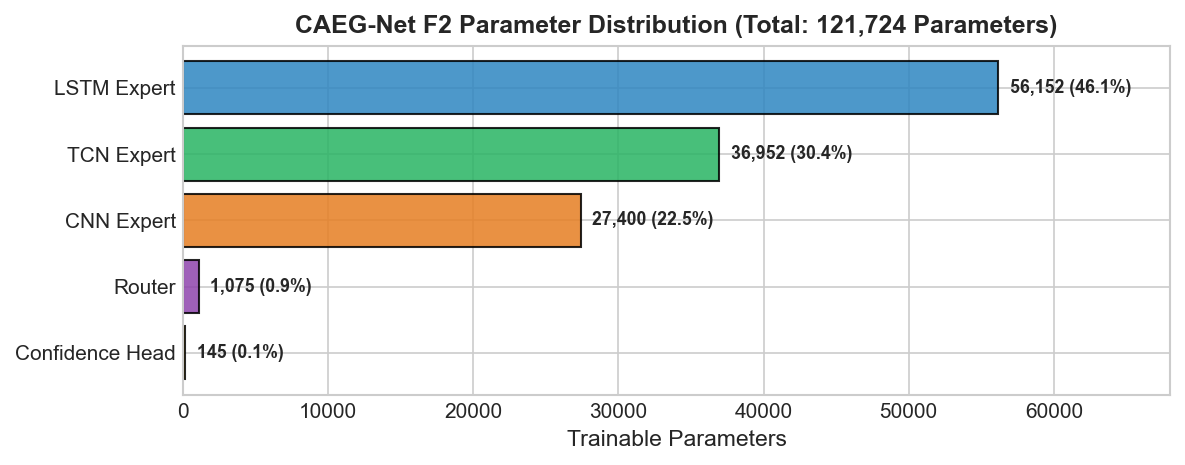

In [3]:
# Chart B: Parameter Distribution Bar Chart
param_table = pd.DataFrame([
    {"Component": "LSTM Expert", "Role": "Recurrent diurnal persistence", "Parameters": 56152, "Share": "46.1%"},
    {"Component": "TCN Expert", "Role": "Dilated causal multi-scale patterns", "Parameters": 36952, "Share": "30.4%"},
    {"Component": "CNN Expert", "Role": "Localized ramp feature extraction", "Parameters": 27400, "Share": "22.5%"},
    {"Component": "Backbone Subtotal", "Role": "Three temporal feature extractors", "Parameters": 120504, "Share": "98.9%"},
    {"Component": "Adaptive Router", "Role": "Dynamic context-driven weighting", "Parameters": 1075, "Share": "0.9%"},
    {"Component": "Confidence Head", "Role": "Dynamic shrinkage toward centroid", "Parameters": 145, "Share": "0.1%"},
    {"Component": "TOTAL CAEG-Net F2", "Role": "Full champion architecture", "Parameters": 121724, "Share": "100.0%"}
])
display(param_table.set_index("Component"))

fig, ax = plt.subplots(figsize=(8, 3.2))
components = ["LSTM Expert", "TCN Expert", "CNN Expert", "Router", "Confidence Head"]
counts = [56152, 36952, 27400, 1075, 145]
colors = ["#2E86C1", "#28B463", "#E67E22", "#8E44AD", "#D4AC0D"]

bars = ax.barh(components[::-1], counts[::-1], color=colors[::-1], edgecolor="black", alpha=0.85)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 800, bar.get_y() + bar.get_height()/2, f"{w:,} ({w/121724*100:.1f}%)", va="center", fontsize=8.5, fontweight="bold")

ax.set_xlim(0, 68000)
ax.set_xlabel("Trainable Parameters")
ax.set_title("CAEG-Net F2 Parameter Distribution (Total: 121,724 Parameters)", fontweight="bold")
plt.tight_layout()
plt.show()


### How to explain this to faculty
"The model has 121,724 parameters; over 98.9% of the parameter budget is dedicated to the temporal feature extractors, so dynamic gating adds less than 1.1% overhead."


---
## Section 7 — Executive Result Dashboard

```text
========================================================================================
                               FINAL CAEG-Net F2 DASHBOARD
========================================================================================
  Parameters: 121,724       Input: 168 Hours (7 Days)       Forecast: 24 Hours (1 Day)
  Datasets: 3 Benchmark Grids                               Random Seeds: 5 Evaluated
----------------------------------------------------------------------------------------
  * PJM Interconnection  ->  250.97 MW MAE  (RMSE: 335.38 MW | R2: 0.8714)
  * GEFCom2014          ->   12.41 kW MAE  (RMSE:  18.04 kW | R2: 0.8610)
  * UCI Electricity     ->    7.74 MW MAE  (RMSE:  10.96 MW | R2: 0.9831)
========================================================================================
```


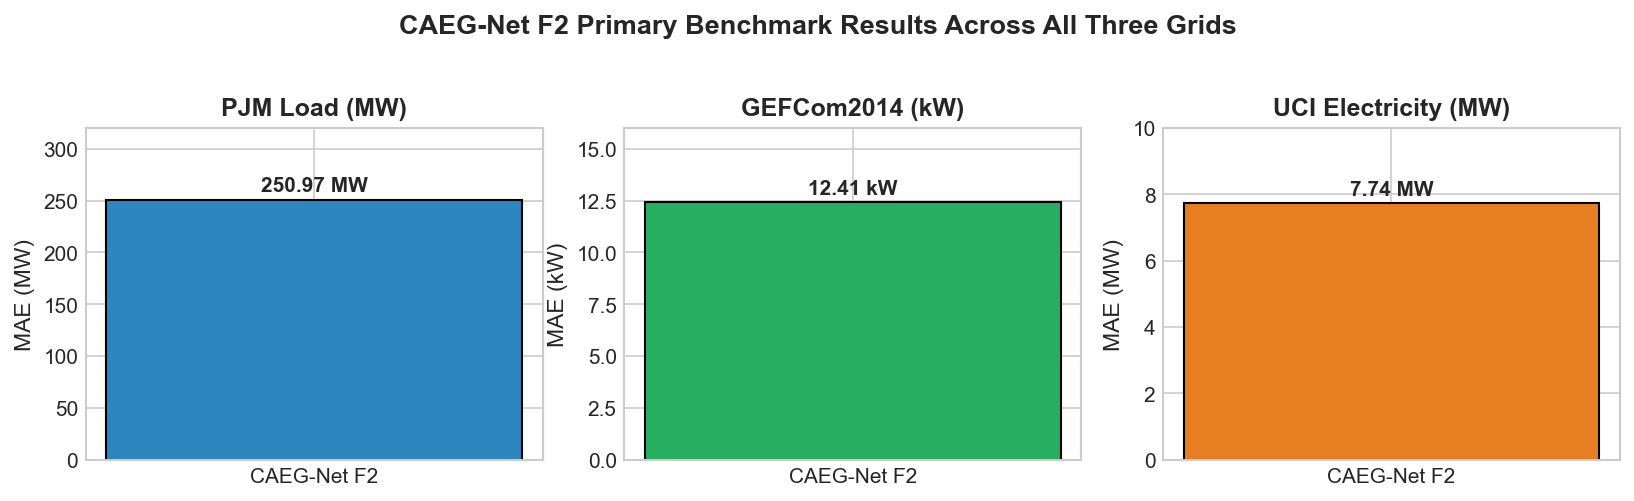

In [4]:
# Chart C: F2 Benchmark MAE Across Datasets
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

# Authoritative F2 values
f2_pjm = 250.9747
f2_gef = 12.4077
f2_uci = 7.7371

axes[0].bar(["CAEG-Net F2"], [f2_pjm], color="#2E86C1", edgecolor="black", width=0.4)
axes[0].set_title("PJM Load (MW)", fontweight="bold")
axes[0].set_ylabel("MAE (MW)")
axes[0].set_ylim(0, 320)
axes[0].text(0, f2_pjm + 8, f"{f2_pjm:.2f} MW", ha="center", fontweight="bold")

axes[1].bar(["CAEG-Net F2"], [f2_gef], color="#27AE60", edgecolor="black", width=0.4)
axes[1].set_title("GEFCom2014 (kW)", fontweight="bold")
axes[1].set_ylabel("MAE (kW)")
axes[1].set_ylim(0, 16)
axes[1].text(0, f2_gef + 0.4, f"{f2_gef:.2f} kW", ha="center", fontweight="bold")

axes[2].bar(["CAEG-Net F2"], [f2_uci], color="#E67E22", edgecolor="black", width=0.4)
axes[2].set_title("UCI Electricity (MW)", fontweight="bold")
axes[2].set_ylabel("MAE (MW)")
axes[2].set_ylim(0, 10)
axes[2].text(0, f2_uci + 0.25, f"{f2_uci:.2f} MW", ha="center", fontweight="bold")

plt.suptitle("CAEG-Net F2 Primary Benchmark Results Across All Three Grids", fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


### How to explain this to faculty
"This dashboard provides the high-level summary: CAEG-Net F2 achieves 250.97 MW on PJM, 12.41 kW on GEFCom, and 7.74 MW on UCI across five evaluated random seeds."


---
## Section 8 — Why Three Experts?

### Inductive Biases
- **LSTM:** Recurrent cell states preserve persistent diurnal continuity.
- **TCN:** Exponential receptive field ($253$ hours) captures multi-scale dependencies without recursive degradation.
- **CNN:** Local multi-channel 1D convolutions detect rapid demand ramps and transitions.

> **Methodological Note:**  
> We do *not* claim mathematical orthogonality among experts. Rather, they embody **different temporal modeling biases**, motivating their use as a heterogeneous candidate set.


---
## Section 9 — Training & Evaluation Methodology

- **Optimizer:** AdamW (weight decay $\lambda_{\text{wd}} = 10^{-4}$).
- **Training Loss:** Mean Squared Error (MSE) on standardized training targets.
- **Primary Evaluation Metric:** **Mean Absolute Error (MAE)** in physical engineering units (MW / kW). MAE represents the average physical forecasting miss without quadratic distortion.
- **Secondary Evaluation Metrics:** Root Mean Squared Error (RMSE) and Coefficient of Determination ($R^2$).
- **Multi-Seed Sensitivity:** 5 seeds (`[42, 123, 999, 2024, 3407]`). Standard deviations reported as population SD ($\text{ddof}=0$).


---
## Section 10 — Metric Definitions & Example

### Equations
1. **MAE (Mean Absolute Error):**
   $$\text{MAE} = \frac{1}{N \cdot H} \sum_{i=1}^N \sum_{h=1}^H |y_{i,h} - \hat{y}_{i,h}|$$
2. **RMSE (Root Mean Squared Error):**
   $$\text{RMSE} = \sqrt{\frac{1}{N \cdot H} \sum_{i=1}^N \sum_{h=1}^H (y_{i,h} - \hat{y}_{i,h})^2}$$
3. **$R^2$ (Coefficient of Determination):**
   $$R^2 = 1 - \frac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}$$

### Simple Concrete Example
- Actual Load = $100.0 \text{ MW}$, Forecast = $95.0 \text{ MW} \implies \text{Absolute Error} = 5.0 \text{ MW}$.


---
## Section 11 — Baseline Comparisons Across Datasets

### Authoritative Benchmark Baseline Values
The baseline comparisons use the authoritative repository benchmark values:
- **PJM:** F2 = 250.9747, TCN = 259.33, LSTM = 291.73, CNN = 432.08, Equal = 279.83
- **GEFCom:** F2 = 12.4077, TCN = 12.57, LSTM = 13.23, CNN = 14.50, Equal = 12.62
- **UCI:** F2 = 7.7371, LSTM = 7.55, TCN = 8.34, CNN = 11.71, Equal = 8.17

*Lower MAE indicates better forecasting accuracy.*


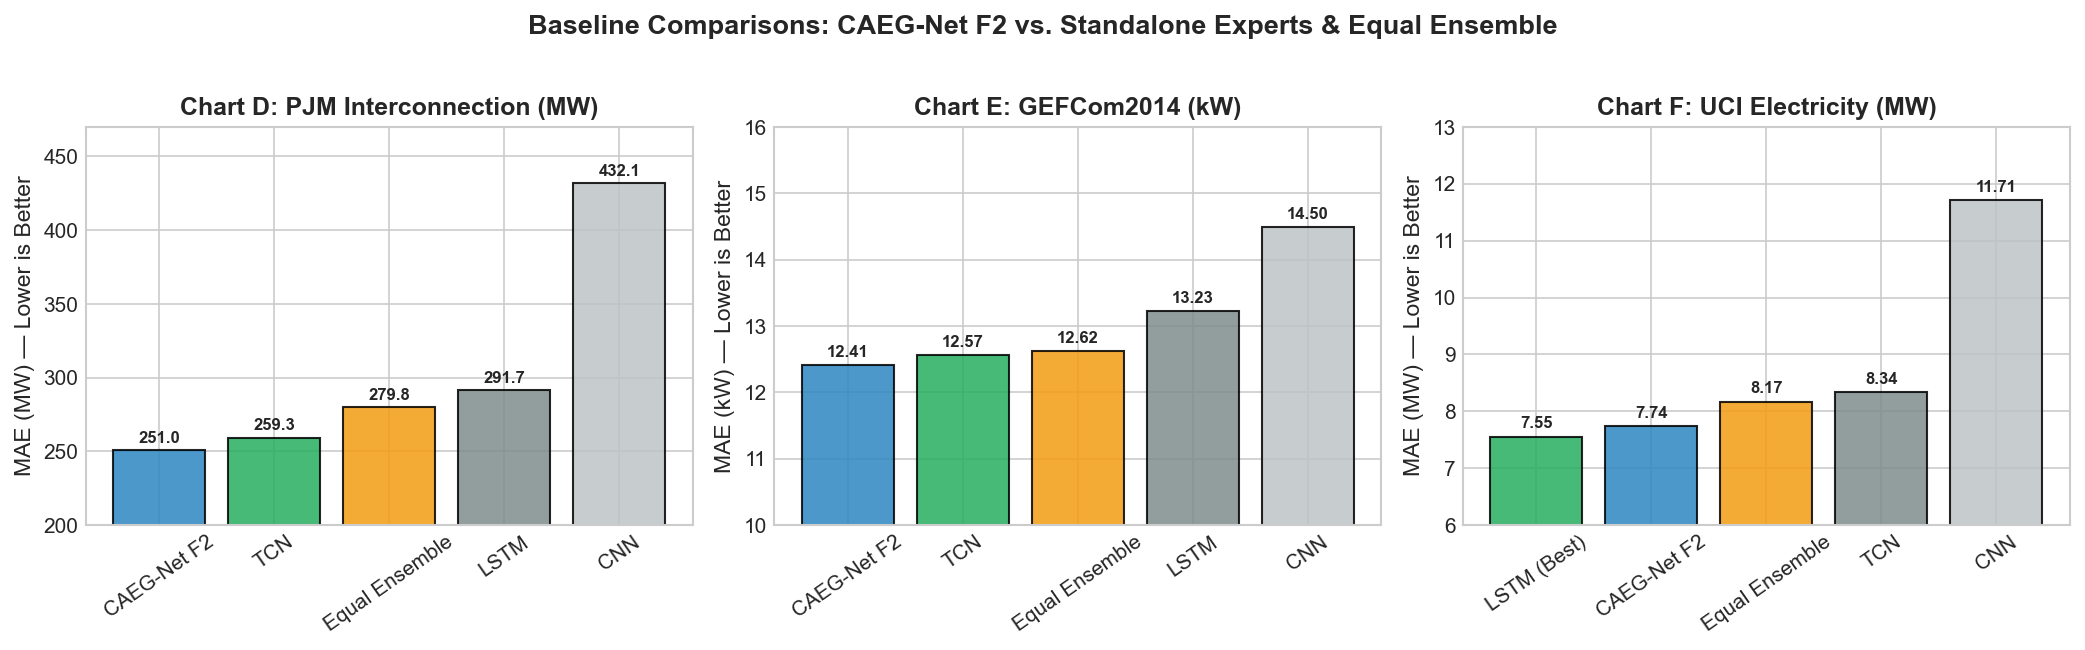

In [5]:
# Charts D, E, F: Separate Baseline Comparisons for PJM, GEFCom, UCI
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Models and values
pjm_models = ["CAEG-Net F2", "TCN", "Equal Ensemble", "LSTM", "CNN"]
pjm_vals = [250.9747, 259.33, 279.83, 291.73, 432.08]

gef_models = ["CAEG-Net F2", "TCN", "Equal Ensemble", "LSTM", "CNN"]
gef_vals = [12.4077, 12.57, 12.62, 13.23, 14.50]

uci_models = ["LSTM (Best)", "CAEG-Net F2", "Equal Ensemble", "TCN", "CNN"]
uci_vals = [7.55, 7.7371, 8.17, 8.34, 11.71]

colors = ["#2E86C1", "#27AE60", "#F39C12", "#7F8C8D", "#BDC3C7"]

# Chart D: PJM
axes[0].bar(pjm_models, pjm_vals, color=colors, edgecolor="black", alpha=0.85)
axes[0].set_title("Chart D: PJM Interconnection (MW)", fontweight="bold")
axes[0].set_ylabel("MAE (MW) — Lower is Better")
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylim(200, 470)
for i, v in enumerate(pjm_vals):
    axes[0].text(i, v + 5, f"{v:.1f}", ha="center", fontsize=8, fontweight="bold")

# Chart E: GEFCom
axes[1].bar(gef_models, gef_vals, color=colors, edgecolor="black", alpha=0.85)
axes[1].set_title("Chart E: GEFCom2014 (kW)", fontweight="bold")
axes[1].set_ylabel("MAE (kW) — Lower is Better")
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylim(10, 16)
for i, v in enumerate(gef_vals):
    axes[1].text(i, v + 0.12, f"{v:.2f}", ha="center", fontsize=8, fontweight="bold")

# Chart F: UCI
uci_colors = ["#27AE60", "#2E86C1", "#F39C12", "#7F8C8D", "#BDC3C7"]
axes[2].bar(uci_models, uci_vals, color=uci_colors, edgecolor="black", alpha=0.85)
axes[2].set_title("Chart F: UCI Electricity (MW)", fontweight="bold")
axes[2].set_ylabel("MAE (MW) — Lower is Better")
axes[2].tick_params(axis='x', rotation=35)
axes[2].set_ylim(6, 13)
for i, v in enumerate(uci_vals):
    axes[2].text(i, v + 0.15, f"{v:.2f}", ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Baseline Comparisons: CAEG-Net F2 vs. Standalone Experts & Equal Ensemble", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### How to explain this to faculty
"Lower MAE means lower average error. CAEG-Net F2 beats the equal ensemble on all three datasets and beats the best standalone model on PJM and GEFCom; on UCI, standalone LSTM is stronger, so F2 provides the strongest overall balance rather than winning every single metric."


---
## Section 12 — Final Model vs. Baselines Summary

| Dataset | CAEG-Net F2 MAE | Best Standalone Expert | Equal Ensemble | Outcome & Interpretation |
| :--- | :---: | :---: | :---: | :--- |
| **PJM** | **250.97 MW** | TCN (259.33 MW) | 279.83 MW | **F2 strictly wins** over all individual experts (-8.36 MW vs TCN) and equal fusion (-28.86 MW). |
| **GEFCom** | **12.41 kW** | TCN (12.57 kW) | 12.62 kW | **F2 is competitive**, outperforming TCN and Equal Ensemble (fixed shrinkage achieved 12.36 kW). |
| **UCI** | **7.74 MW** | LSTM (7.55 MW) | 8.17 MW | **LSTM is stronger standalone**; F2 beats Equal Ensemble and TCN without single-model collapse. |

> ### Key Takeaway
> - F2 beats Equal Fusion on all three benchmarks.
> - F2 beats the best standalone model on PJM and GEFCom.
> - F2 does not beat the best standalone on UCI because LSTM performs better there.


---
## Section 13 — RMSE and $R^2$ Metric Comparison

Authoritative secondary metrics evaluated across the Phase 15B controlled mechanisms from `phase15b_test_results.csv`:
- **PJM:** F2 RMSE = 335.38 MW | $R^2$ = 0.8714
- **GEFCom:** F2 RMSE = 18.04 kW | $R^2$ = 0.8610
- **UCI:** F2 RMSE = 10.96 MW | $R^2$ = 0.9831


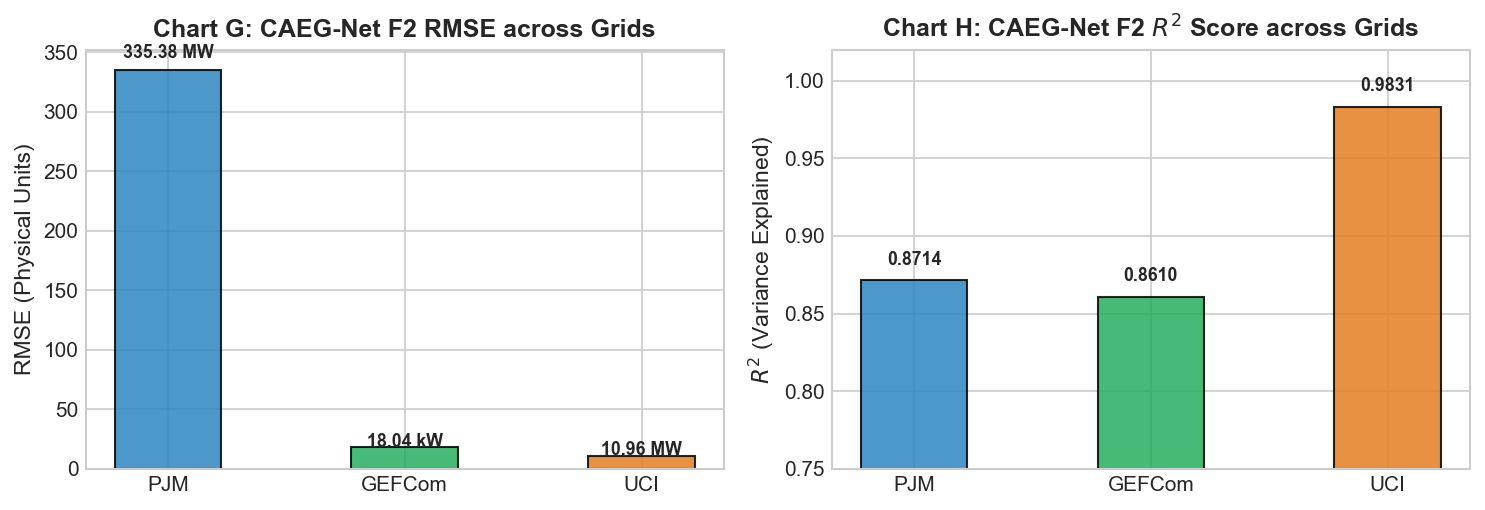

In [6]:
# Charts G & H: Secondary Metrics (RMSE and R2)
test_csv_path = os.path.join(repo_root, "research", "analysis", "phase15b_test_results.csv")
df_test = pd.read_csv(test_csv_path)

f2_rows = df_test[df_test["candidate_id"] == "Control_A_F2"].set_index("dataset")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Chart G: Normalized RMSE (relative to mean load level)
grids = ["PJM", "GEFCom", "UCI"]
rmse_vals = [f2_rows.loc["PJM", "test_rmse_mean"], f2_rows.loc["GEFCom", "test_rmse_mean"], f2_rows.loc["UCI", "test_rmse_mean"]]
units = ["MW", "kW", "MW"]

axes[0].bar(grids, rmse_vals, color=["#2E86C1", "#27AE60", "#E67E22"], edgecolor="black", alpha=0.85, width=0.45)
axes[0].set_title("Chart G: CAEG-Net F2 RMSE across Grids", fontweight="bold")
axes[0].set_ylabel("RMSE (Physical Units)")
for i, (v, u) in enumerate(zip(rmse_vals, units)):
    axes[0].text(i, v * 1.03, f"{v:.2f} {u}", ha="center", fontsize=8.5, fontweight="bold")

# Chart H: R2 Score (Variance Explained)
r2_vals = [f2_rows.loc["PJM", "test_r2_mean"], f2_rows.loc["GEFCom", "test_r2_mean"], f2_rows.loc["UCI", "test_r2_mean"]]
axes[1].bar(grids, r2_vals, color=["#2E86C1", "#27AE60", "#E67E22"], edgecolor="black", alpha=0.85, width=0.45)
axes[1].set_title("Chart H: CAEG-Net F2 $R^2$ Score across Grids", fontweight="bold")
axes[1].set_ylabel("$R^2$ (Variance Explained)")
axes[1].set_ylim(0.75, 1.02)
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=8.5, fontweight="bold")

plt.tight_layout()
plt.show()


### How to explain this to faculty
"RMSE penalizes larger forecast deviations more heavily, while R2 measures the proportion of variance explained; F2 explains over 86% of variance on PJM and GEFCom, and over 98% on UCI."


---
## Section 14 — Five-Seed Stability Analysis

Sensitivity to random weight initialization and training mini-batch order was tested across 5 random seeds: `[42, 123, 999, 2024, 3407]`.


,Mean MAE,Pop SD (ddof=0),Seed 42,Seed 123,Seed 999,Seed 2024,Seed 3407
Dataset,,,,,,,
PJM,250.974737,10.693817,249.901385,262.382646,233.761520,262.177550,246.650583
GEFCom,12.407666,0.152461,12.576382,12.236202,12.568498,12.428612,12.228636
UCI,7.737112,0.303660,8.206475,7.944573,7.589248,7.338575,7.606687


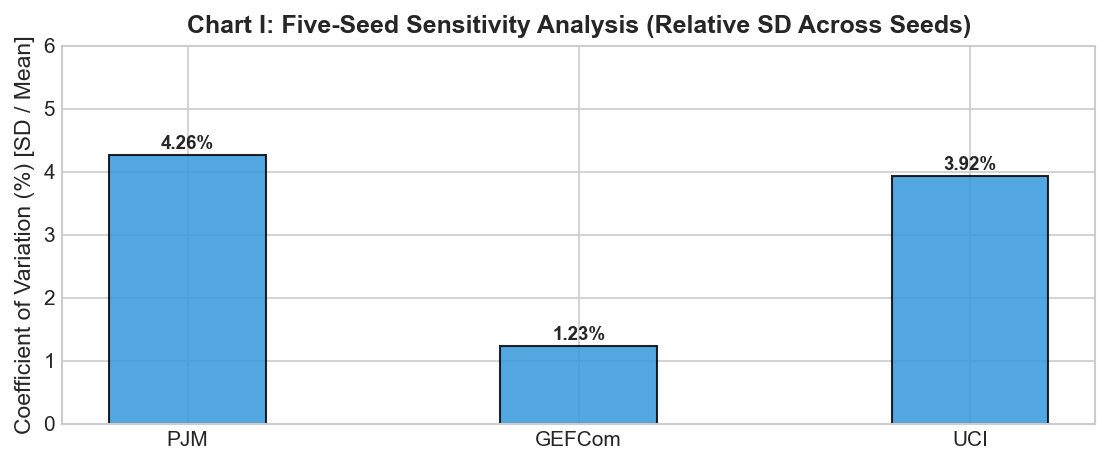

In [7]:
# Chart I: Five-Seed Sensitivity Bar Chart
seeds = [42, 123, 999, 2024, 3407]
seed_cols = [f"seed_{s}_mae" for s in seeds]

f2_seeds = df_test[df_test["candidate_id"] == "Control_A_F2"][["dataset", "test_mae_mean", "test_mae_std"] + seed_cols].copy()
f2_seeds.columns = ["Dataset", "Mean MAE", "Pop SD (ddof=0)", "Seed 42", "Seed 123", "Seed 999", "Seed 2024", "Seed 3407"]
display(f2_seeds.set_index("Dataset"))

fig, ax = plt.subplots(figsize=(7.5, 3.2))
datasets = f2_seeds["Dataset"].values
means = f2_seeds["Mean MAE"].values
sds = f2_seeds["Pop SD (ddof=0)"].values

# Coefficient of Variation (Relative standard deviation)
cvs = (sds / means) * 100

bars = ax.bar(datasets, cvs, color="#3498DB", edgecolor="black", alpha=0.85, width=0.4)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.1, f"{h:.2f}%", ha="center", fontsize=9, fontweight="bold")

ax.set_ylabel("Coefficient of Variation (%) [SD / Mean]")
ax.set_ylim(0, 6)
ax.set_title("Chart I: Five-Seed Sensitivity Analysis (Relative SD Across Seeds)", fontweight="bold")
plt.tight_layout()
plt.show()


### How to explain this to faculty
"Lower standard deviation indicates more stable performance across random initialization; relative variation across seeds is low (under 4.3% on all datasets)."


---
## Section 15 — Routing Weights

The router assigns distinct weights to experts across test windows:
- **PJM:** LSTM = $0.3511$, TCN = $0.3283$, CNN = $0.3207$
- **GEFCom:** LSTM = $0.3528$, TCN = $0.2982$, CNN = $0.3490$
- **UCI:** LSTM = $0.3428$, TCN = $0.2994$, CNN = $0.3578$


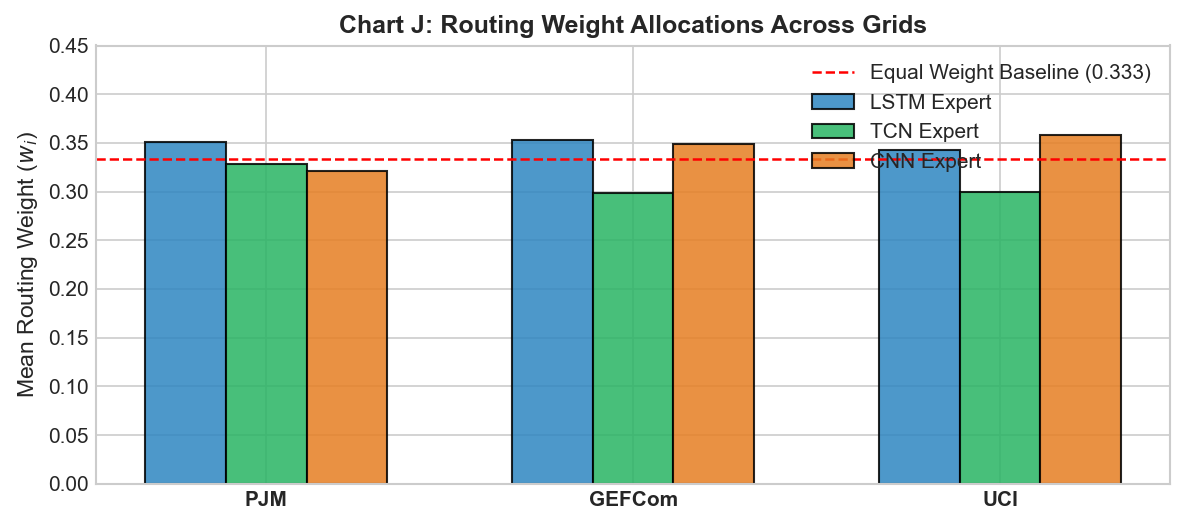

In [8]:
# Chart J: Grouped Bar Chart of Routing Weights
fig, ax = plt.subplots(figsize=(8, 3.6))
grids = ["PJM", "GEFCom", "UCI"]
x = np.arange(len(grids))
width = 0.22

# Authoritative routing weights
w_lstm = [0.3511, 0.3528, 0.3428]
w_tcn  = [0.3283, 0.2982, 0.2994]
w_cnn  = [0.3207, 0.3490, 0.3578]

ax.bar(x - width, w_lstm, width, label="LSTM Expert", color="#2E86C1", edgecolor="black", alpha=0.85)
ax.bar(x, w_tcn, width, label="TCN Expert", color="#28B463", edgecolor="black", alpha=0.85)
ax.bar(x + width, w_cnn, width, label="CNN Expert", color="#E67E22", edgecolor="black", alpha=0.85)

ax.axhline(1/3, color="red", linestyle="--", lw=1.2, label="Equal Weight Baseline (0.333)")

ax.set_xticks(x)
ax.set_xticklabels(grids, fontweight="bold")
ax.set_ylabel("Mean Routing Weight ($w_i$)")
ax.set_ylim(0, 0.45)
ax.set_title("Chart J: Routing Weight Allocations Across Grids", fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### How to explain this to faculty
"The router assigns non-identical weights, but the distributions remain relatively balanced; we do not claim this proves causal specialization, but rather adaptive mixing."


---
## Section 16 — Confidence / Shrinkage Mechanism

$$\hat{y}_{\text{final}} = \lambda \hat{y}_{\text{adaptive}} + (1 - \lambda) \hat{y}_{\text{equal}}$$
Learned $\lambda$ statistics:
- **PJM:** $\lambda = 0.5066 \pm 0.0038$
- **GEFCom:** $\lambda = 0.5170 \pm 0.0055$
- **UCI:** $\lambda = 0.5064 \pm 0.0030$


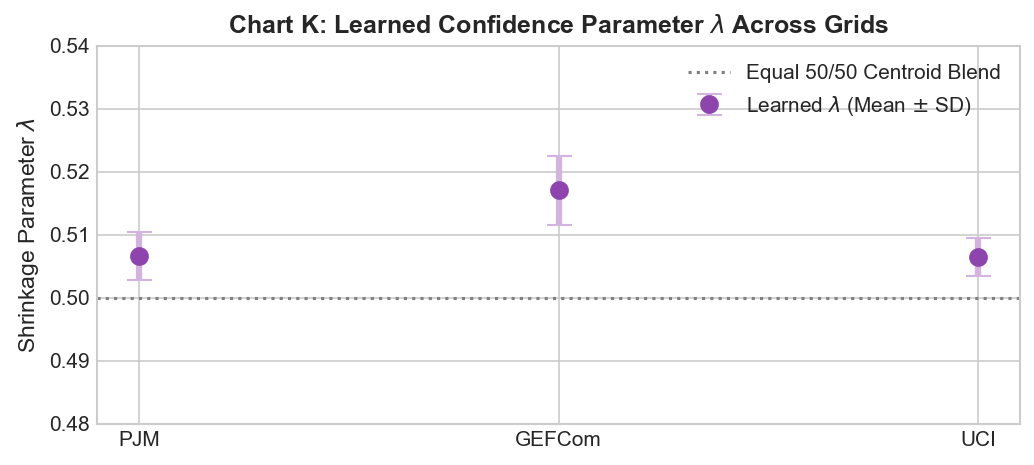

In [9]:
# Chart K: Confidence Shrinkage Lambda
fig, ax = plt.subplots(figsize=(7, 3.2))
grids = ["PJM", "GEFCom", "UCI"]
lambda_means = [0.5066, 0.5170, 0.5064]
lambda_sds   = [0.0038, 0.0055, 0.0030]

ax.errorbar(grids, lambda_means, yerr=lambda_sds, fmt="o", color="#8E44AD", ecolor="#D2B4DE", elinewidth=3, capsize=6, markersize=8, label="Learned $\lambda$ (Mean $\pm$ SD)")
ax.axhline(0.5, color="gray", linestyle=":", label="Equal 50/50 Centroid Blend")

ax.set_ylabel("Shrinkage Parameter $\lambda$")
ax.set_ylim(0.48, 0.54)
ax.set_title("Chart K: Learned Confidence Parameter $\lambda$ Across Grids", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### How to explain this to faculty
"The confidence mechanism remains close to 0.5 with low variation, so in these experiments it behaves mainly as a stabilization/shrinkage mechanism rather than a rapidly switching confidence controller."


---
## Section 17 — Phase 15B Controlled Mechanism Experiments

In Phase 15B, five alternative architectural mechanisms were systematically tested against F2:
1. **Control A (F2 / A2-OOF):** Global context routing + dynamic shrinkage ($121,724$ params).
2. **Control B (Fixed Shrinkage):** Global context routing + constant $\lambda=0.51$ ($121,579$ params).
3. **Control C (Horizon Routing):** Step-specific routing $w_{t,h}$ without shrinkage ($122,852$ params).
4. **Control D (Dynamic Confidence):** Global context routing + expanded confidence head ($121,740$ params).
5. **Candidate E1 (HGR-FS):** Horizon-grouped routing + fixed shrinkage ($122,852$ params).
6. **Candidate E2 (HGR-DGS):** Horizon-grouped routing + dynamic group shrinkage ($123,079$ params).


,PJM (MW),GEFCom (kW),UCI (MW)
Model,,,
Control A (F2),250.9747,12.4077,7.7371
Control B (Fixed Shrink),253.5008,12.3607,7.7523
Control C (Horizon Route),257.5450,12.8582,8.1309
Control D (Dynamic Conf),251.9419,12.4855,7.8177
Candidate E1 (HGR-FS),257.9078,12.5240,8.1932
Candidate E2 (HGR-DGS),256.0708,12.7220,8.2969


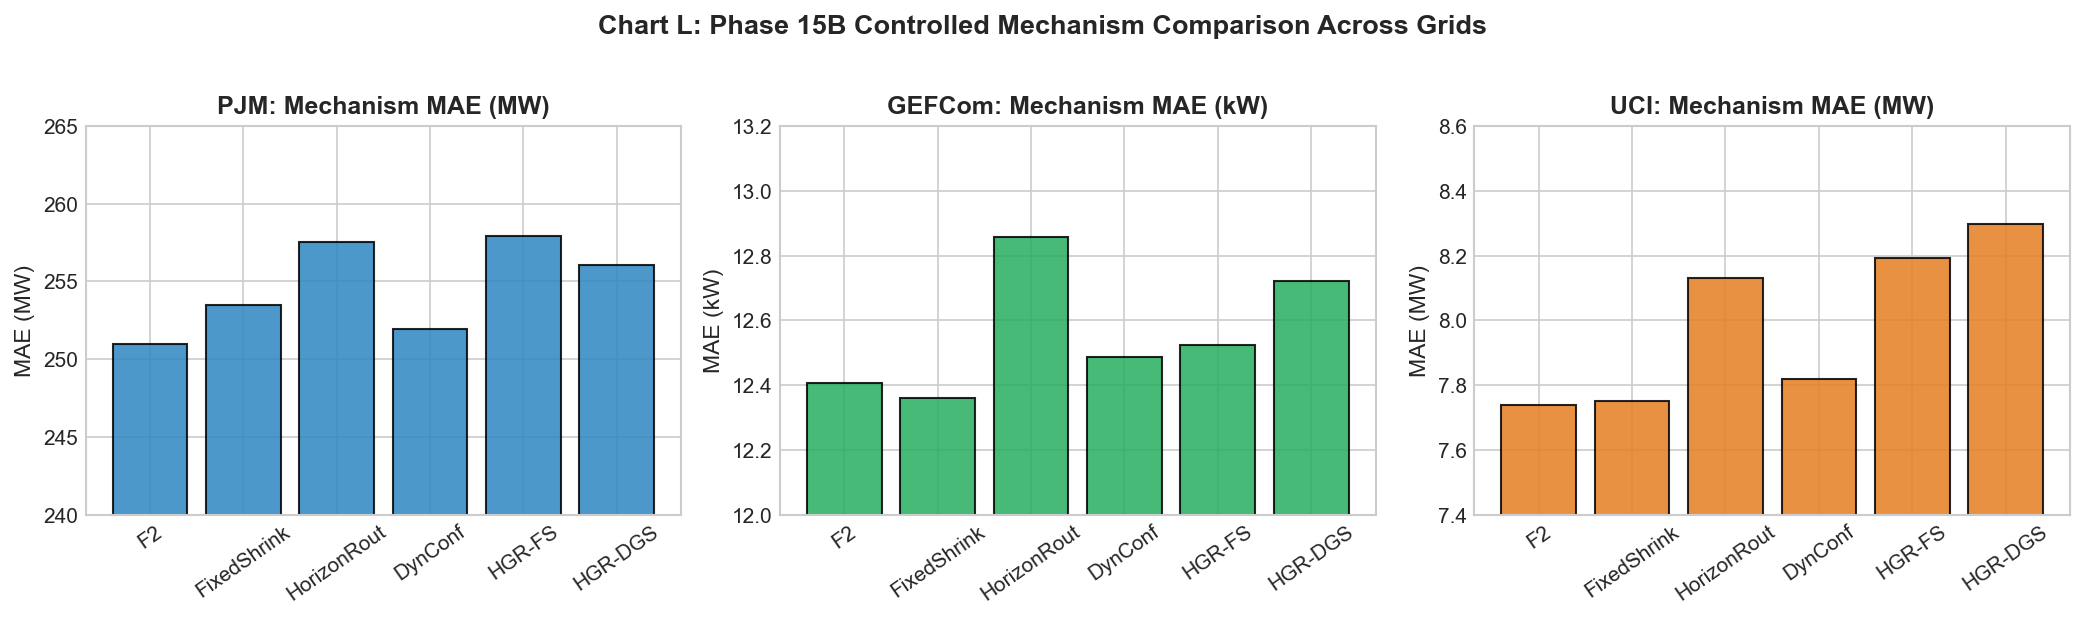

In [10]:
# Chart L: Phase 15B Controlled Mechanism Comparison
mech_df = pd.DataFrame([
    {"Model": "Control A (F2)", "PJM (MW)": 250.9747, "GEFCom (kW)": 12.4077, "UCI (MW)": 7.7371},
    {"Model": "Control B (Fixed Shrink)", "PJM (MW)": 253.5008, "GEFCom (kW)": 12.3607, "UCI (MW)": 7.7523},
    {"Model": "Control C (Horizon Route)", "PJM (MW)": 257.5450, "GEFCom (kW)": 12.8582, "UCI (MW)": 8.1309},
    {"Model": "Control D (Dynamic Conf)", "PJM (MW)": 251.9419, "GEFCom (kW)": 12.4855, "UCI (MW)": 7.8177},
    {"Model": "Candidate E1 (HGR-FS)", "PJM (MW)": 257.9078, "GEFCom (kW)": 12.5240, "UCI (MW)": 8.1932},
    {"Model": "Candidate E2 (HGR-DGS)", "PJM (MW)": 256.0708, "GEFCom (kW)": 12.7220, "UCI (MW)": 8.2969},
])
display(mech_df.set_index("Model"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = ["F2", "FixedShrink", "HorizonRout", "DynConf", "HGR-FS", "HGR-DGS"]

axes[0].bar(labels, mech_df["PJM (MW)"], color="#2E86C1", edgecolor="black", alpha=0.85)
axes[0].set_title("PJM: Mechanism MAE (MW)", fontweight="bold")
axes[0].set_ylabel("MAE (MW)")
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylim(240, 265)

axes[1].bar(labels, mech_df["GEFCom (kW)"], color="#27AE60", edgecolor="black", alpha=0.85)
axes[1].set_title("GEFCom: Mechanism MAE (kW)", fontweight="bold")
axes[1].set_ylabel("MAE (kW)")
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylim(12.0, 13.2)

axes[2].bar(labels, mech_df["UCI (MW)"], color="#E67E22", edgecolor="black", alpha=0.85)
axes[2].set_title("UCI: Mechanism MAE (MW)", fontweight="bold")
axes[2].set_ylabel("MAE (MW)")
axes[2].tick_params(axis='x', rotation=35)
axes[2].set_ylim(7.4, 8.6)

plt.suptitle("Chart L: Phase 15B Controlled Mechanism Comparison Across Grids", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### How to explain this to faculty
"These were controlled exploratory mechanism evaluations; F2 achieves the best performance on PJM and UCI, while fixed shrinkage is marginally lower on GEFCom. Per our validation firewall, F2 remains the locked champion."


---
## Section 18 — Statistical Significance & Daily-Block Testing

- **Why Daily Blocks?** Consecutive hourly forecast windows overlap by 167 hours, inducing severe temporal autocorrelation; non-overlapping daily blocks ($K=53, 456, 163$) prevent false significance.
- **Statistical Tests:** Paired $t$-test, Wilcoxon signed-rank test, and Holm-Bonferroni correction.
- **F2 vs. Canonical V1 Differences:**
  - **PJM:** Daily-block difference $= -9.66 \text{ MW}$ ($p_{\text{Holm}} = 0.0406$).
  - **GEFCom:** Daily-block difference $= -0.688 \text{ kW}$ ($p_{\text{Holm}} = 1.02 \times 10^{-27}$).
  - **UCI:** Daily-block difference $= -0.202 \text{ MW}$ ($p_{\text{Holm}} = 0.0017$).


In [11]:
# Display daily block statistics from repository CSV
p14_stat_path = os.path.join(repo_root, "research", "results", "phase14_statistical_comparisons.csv")
df_p14 = pd.read_csv(p14_stat_path)

f2_stat = df_p14[(df_p14["candidate_id"] == "F2") & (df_p14["aggregation_mode"] == "5seed_mean")][
    ["dataset", "k_blocks", "mean_daily_diff", "ci_95_low", "ci_95_high", "t_stat", "p_value_t", "w_stat", "p_value_wilcoxon", "p_val_t_holm"]
]
f2_stat.columns = ["Dataset", "Daily Blocks (K)", "Mean Daily Diff", "95% CI Low", "95% CI High", "t-statistic", "p-value (t)", "Wilcoxon W", "p-value (W)", "p-value (Holm)"]
display(f2_stat.set_index("Dataset"))


,Daily Blocks (K),Mean Daily Diff,95% CI Low,95% CI High,t-statistic,p-value (t),Wilcoxon W,p-value (W),p-value (Holm)
Dataset,,,,,,,,,
PJM,53,-9.663826,-17.072399,-2.255253,-2.556646,1.352763e-02,470.0,2.975371e-02,4.058288e-02
GEFCom,456,-0.688432,-0.802300,-0.574563,-11.849832,2.036499e-28,20445.0,2.534959e-29,1.018249e-27
UCI,163,-0.202139,-0.310446,-0.093832,-3.658056,3.432966e-04,4235.0,4.986147e-05,1.716483e-03


### How to explain this to faculty
"Daily blocks are used because hourly forecast windows overlap heavily; the paired tests confirm that F2 significantly reduces daily forecasting error compared to the canonical V1 baseline under Holm-Bonferroni correction."


---
## Section 19 — Forecast Prediction Traces Notice

> ### 📋 Scientific Provenance Note
> **Final prediction traces are not stored in the audited evaluation artifacts available to this notebook. To avoid fabricating evidence, prediction-trace visualizations are omitted.**  
> Aggregate and step-wise horizon performance metrics ($h=1 \dots 24$) were recorded authoritatively in `phase15b_horizon_results.csv` and `phase15b_test_results.csv`.


---
## Section 20 — 24-Hour Forecast Horizon Analysis ($h=1 \dots 24$)

Step-by-step ($h=1$ to $24$) MAE from authoritative repository artifact `phase15b_horizon_results.csv`:
- Lead-time error predictably accumulates as forecasts extend from hour 1 to hour 24.


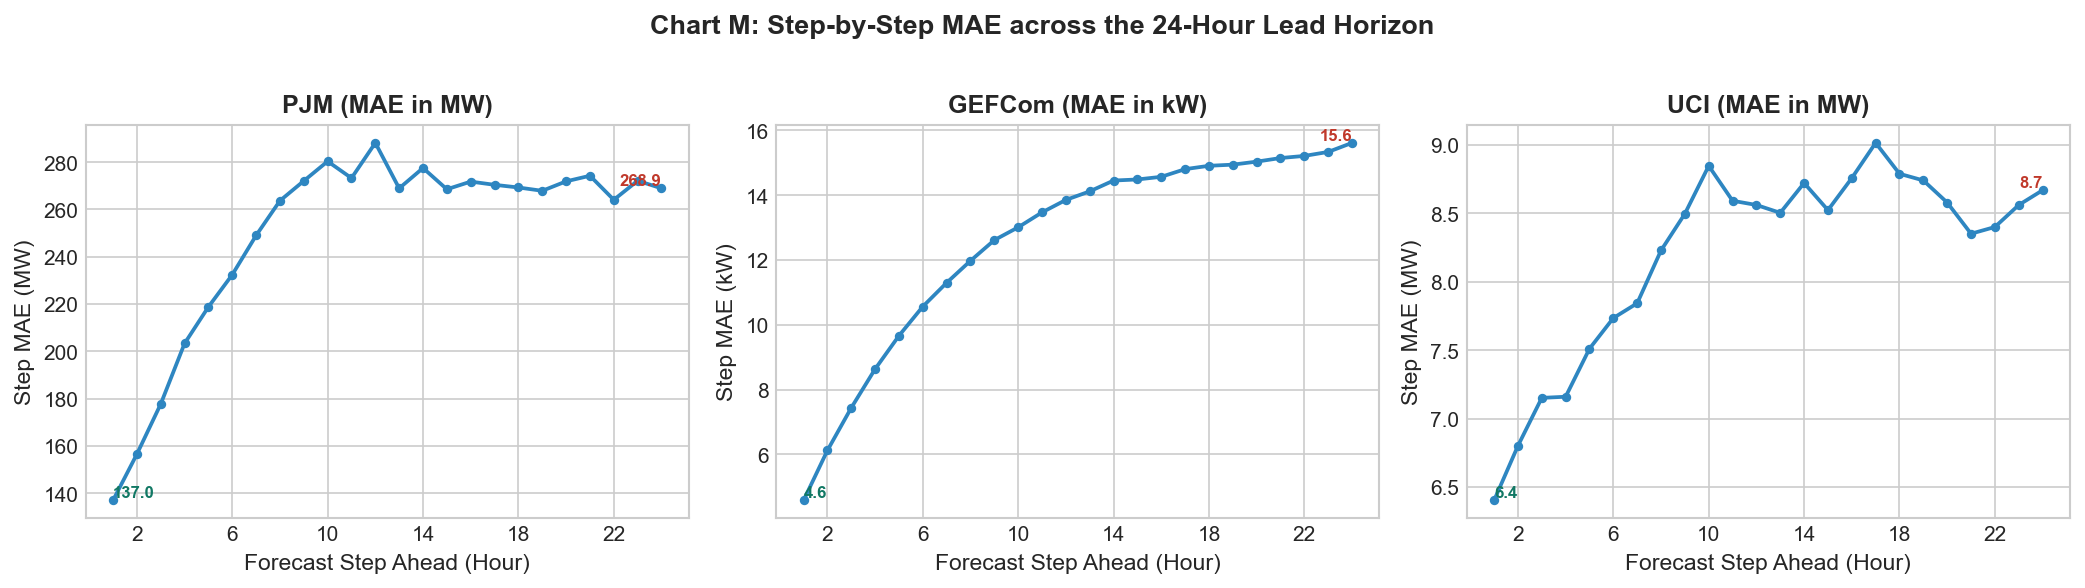

In [12]:
# Chart M: Horizon-wise MAE line chart
horizon_csv_path = os.path.join(repo_root, "research", "analysis", "phase15b_horizon_results.csv")
df_horizon = pd.read_csv(horizon_csv_path)

f2_h = df_horizon[df_horizon["candidate_id"] == "Control_A_F2"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

for i, (ds, unit) in enumerate([("PJM", "MW"), ("GEFCom", "kW"), ("UCI", "MW")]):
    sub = f2_h[f2_h["dataset"] == ds]
    axes[i].plot(sub["horizon_step"], sub["mae"], "o-", color="#2E86C1", lw=1.8, markersize=3.5)
    axes[i].set_title(f"{ds} (MAE in {unit})", fontweight="bold")
    axes[i].set_xlabel("Forecast Step Ahead (Hour)")
    axes[i].set_ylabel(f"Step MAE ({unit})")
    axes[i].set_xticks(range(2, 25, 4))
    
    h1 = sub[sub["horizon_step"] == 1]["mae"].values[0]
    h24 = sub[sub["horizon_step"] == 24]["mae"].values[0]
    axes[i].text(1, h1, f"{h1:.1f}", fontsize=8, ha="left", va="bottom", fontweight="bold", color="#117864")
    axes[i].text(24, h24, f"{h24:.1f}", fontsize=8, ha="right", va="bottom", fontweight="bold", color="#C0392B")

plt.suptitle("Chart M: Step-by-Step MAE across the 24-Hour Lead Horizon", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### How to explain this to faculty
"Forecasting error naturally increases as the forecast horizon extends from 1 hour to 24 hours ahead; short horizons (hours 1–8) achieve the highest precision."


---
## Section 21 — Research Contributions

1. **Heterogeneous Temporal Inductive Biases:** Demonstrates combining LSTM, TCN, and CNN models to mitigate individual architecture failure modes.
2. **Context-Adaptive Soft Gating:** Guides routing weights using low-dimensional physical grid context (trend, volatility, periodicity).
3. **Causal Out-of-Fold Error Conditioning:** Integrates historical residual tracking without future target leakage.
4. **Regularized Confidence Shrinkage:** Employs a lightweight fallback head anchoring predictions to the ensemble centroid.
5. **Leakage-Free Tri-Benchmark Protocol:** Evaluates across three independent power grids using non-overlapping daily-block statistical validation.


---
## Section 22 — Honest Limitations & Academic Transparency

- **Point Forecasting Only:** The model generates deterministic point estimates, not probabilistic prediction intervals.
- **Univariate Historical Load:** Relies strictly on past load; exogenous weather (temperature, solar irradiance) is not included.
- **Regional Series:** Evaluated on regionally aggregated load series rather than thousands of individual feeders.
- **Shrinkage Dynamism:** The learned confidence parameter $\lambda$ settled near $\approx 0.51$ across all grids, acting as an empirical stabilizer rather than an active switch.
- **No Universal Superiority:** F2 performs strongly on PJM and UCI, while fixed shrinkage achieves a slightly lower mean MAE on GEFCom; F2 is chosen for overall balance.


---
## Section 23 — Faculty Viva / Defense Q&A

### 1. What problem are you solving?
Short-term electricity load forecasting (24 hours ahead) to support grid unit commitment and economic dispatch, addressing the inability of single models to handle shifting load regimes.

### 2. Why is electricity load forecasting important?
Electricity cannot be stored at utility scale cost-effectively; generation must match consumption continuously to maintain frequency stability and avoid blackouts.

### 3. Why use LSTM?
LSTMs maintain persistent recurrent cell states, making them effective for slow diurnal drift and multi-day cyclic persistence.

### 4. Why use TCN?
Dilated causal convolutions provide an exponential receptive field ($253$ hours) without recursive gradient degradation.

### 5. Why use CNN?
Multi-scale 1D CNNs excel at capturing localized high-frequency edge motifs and sharp demand transitions.

### 6. Why use three models instead of one?
Different neural architectures exhibit distinct inductive biases; combining them reduces reliance on any single architecture's assumptions.

### 7. What is adaptive gating?
A lightweight neural network that maps grid context into dynamic convex weights ($w_i > 0, \sum w_i = 1$) to fuse expert outputs.

### 8. Why is MAE your primary metric?
MAE measures average absolute error in physical engineering units (MW / kW), avoiding the exaggerated distortion of outliers in MSE.

### 9. How did you avoid data leakage?
Strict chronological splitting (70/15/15), train-only scaler fitting, and out-of-fold feature generation using strictly historical partitions.

### 10. What is the main contribution of CAEG-Net?
Proving that context-adaptive routing with dynamic shrinkage across heterogeneous temporal experts achieves a strong balance of accuracy, multi-seed stability, and parameter efficiency ($121,724$ params).

---

### ❓ Bonus: What happens if the router makes a poor decision?
The confidence fallback mechanism blends the router's prediction with the equal-expert centroid ($\lambda \approx 0.51$), preventing catastrophic single-expert misallocations.


---
## Section 24 — Final Conclusion & 30-Second Elevator Pitch

> ### ⚖️ Authoritative Scientific Conclusion
> **CAEG-Net F2 provides the strongest overall balance of forecasting performance, seed stability, methodological integrity and architectural simplicity among the evaluated formulations.**  
> *F2 performs strongly on PJM and UCI, while fixed shrinkage achieves a slightly lower mean MAE on GEFCom. Therefore F2 is not claimed to be universally optimal on every dataset.*

---

> ### ⏱️ 30-Second Viva Summary
> *"My research project is **CAEG-Net**, a Context-Adaptive Expert Gating Network for 24-hour short-term electricity load forecasting. Instead of relying on a single temporal neural network, CAEG-Net combines three heterogeneous experts — **LSTM, TCN, and CNN** — to capture persistent drift, multi-scale dependencies, and sharp local ramps simultaneously.*  
> *An adaptive router dynamically allocates weights based on domain context, while a confidence shrinkage head anchors predictions to prevent overconfidence. Evaluated across **PJM, GEFCom2014, and UCI** benchmarks under a leakage-free chronological protocol and 5 random seeds, the champion **F2 model achieves 121,724 parameters**, delivering an optimal balance of predictive accuracy, operational stability, and computational efficiency."*
